In [1]:
# @title 1) Setup Environment
import sys, os
from google.colab import drive

#!pip install -q --upgrade --quiet torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!apt -y install -qq aria2

# Clone the OFFICIAL ComfyUI repository
!git clone https://github.com/comfyanonymous/ComfyUI.git /content/ComfyUI
!pip install -q -r /content/ComfyUI/requirements.txt

# GGUF custom nodes from city96
!git clone https://github.com/city96/ComfyUI-GGUF.git /content/ComfyUI/custom_nodes/ComfyUI_GGUF
!pip install -q -r /content/ComfyUI/custom_nodes/ComfyUI_GGUF/requirements.txt

comfy_path = "/content/ComfyUI"
if not comfy_path in sys.path:
  sys.path.insert(0, comfy_path)

if not os.path.exists('/content/drive'):
  drive.mount('/content/drive')

faga_path = "/content/drive/MyDrive/AI/Colab/gen_ai"
if not faga_path in sys.path:
  sys.path.insert(0, faga_path)

print("✅ Environment Setup Complete!")

The following additional packages will be installed:
  libaria2-0 libc-ares2
The following NEW packages will be installed:
  aria2 libaria2-0 libc-ares2
0 upgraded, 3 newly installed, 0 to remove and 41 not upgraded.
Need to get 1,513 kB of archives.
After this operation, 5,441 kB of additional disk space will be used.
Selecting previously unselected package libc-ares2:amd64.
(Reading database ... 121689 files and directories currently installed.)
Preparing to unpack .../libc-ares2_1.18.1-1ubuntu0.22.04.3_amd64.deb ...
Unpacking libc-ares2:amd64 (1.18.1-1ubuntu0.22.04.3) ...
Selecting previously unselected package libaria2-0:amd64.
Preparing to unpack .../libaria2-0_1.36.0-1_amd64.deb ...
Unpacking libaria2-0:amd64 (1.36.0-1) ...
Selecting previously unselected package aria2.
Preparing to unpack .../aria2_1.36.0-1_amd64.deb ...
Unpacking aria2 (1.36.0-1) ...
Setting up libc-ares2:amd64 (1.18.1-1ubuntu0.22.04.3) ...
Setting up libaria2-0:amd64 (1.36.0-1) ...
Setting up aria2 (1.36.0-1) 

  0%|          | 0/25 [00:00<?, ?it/s]

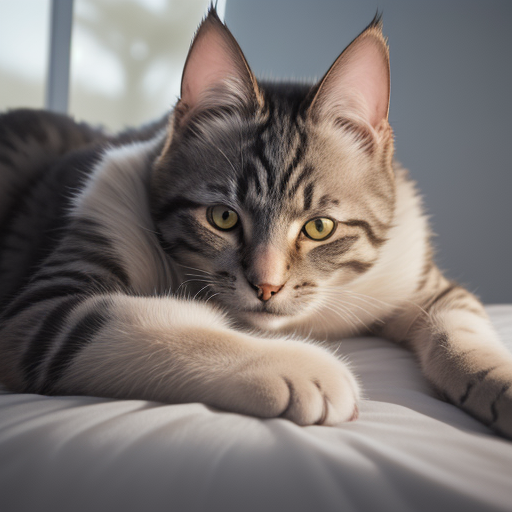

In [3]:
# @title 2) Display Form
import platform
from faga.ui.prompt_form import PromptForm
from faga.ui.ui_helper import UiHelper
from faga.ai.file_manager import FileManager
from faga.ai.model_params import ModelParams
from faga.ai.workflow import Workflow
import ipywidgets as widgets

fm = FileManager("." if platform.system() == "Windows" else "/content/drive/MyDrive/AI/Colab/gen_ai")


def on_generate(model_id: str, prompt: ModelParams):
  if (images := Workflow.generate(fm, model_id, prompt, "/content/ComfyUI")) is not None:
    helper = UiHelper(images, prompt)
    for image in helper.get_images():
      display(image)


form = PromptForm.create_new(fm, on_generate)
display(form.get_style())
display(form.get_header_control())
display(form.get_body_control())